# Week 2 - #03 Machine Learning for NLP

[Scikit-learn: Classification](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning)

- SVM (Support Vector Machine) 
- Naive Bayes

## Assignment

Perform sentiment analysis using SVM and Naive Bayes and compare the results.

Dataset: [vietnamese-text-classification](https://www.kaggle.com/datasets/tuannguyenvananh/vietnamese-text-classification-dataset)

In [297]:
import pandas as pd
import numpy as np
import re
import emoji
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
from underthesea import word_tokenize
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

### Load dataset

In [298]:
# load dataset into dataframe
df = pd.read_csv("../data/train.csv")
df.head()

,0,máy dùng hay bị đơ máy
0,0,chỉ có dây cáp nguồn không có adapter sao sử d...
1,0,Chất lượng quá kém Mới dùng được 2 ngày loa ba...
2,0,Usb tôi vừa mới nhận usb này Rất bực bội vì cá...
3,2,Tuyệt vời. Hàng FPT cửa hàng
4,1,Chưa đo đúng bước chân rõ Nhiều khi gián đoạn ...


In [299]:
# rename columns
df.columns = ['label', 'review']
df.head()

,label,review
0,0,chỉ có dây cáp nguồn không có adapter sao sử d...
1,0,Chất lượng quá kém Mới dùng được 2 ngày loa ba...
2,0,Usb tôi vừa mới nhận usb này Rất bực bội vì cá...
3,2,Tuyệt vời. Hàng FPT cửa hàng
4,1,Chưa đo đúng bước chân rõ Nhiều khi gián đoạn ...


In [300]:
df.shape

(3039, 2)

In [301]:
for i in range(50):
    print(f"Review {i+1}:")
    print(df['review'][i])

Review 1:
chỉ có dây cáp nguồn không có adapter sao sử dụng chỉ có dây cáp nguồn không có adapter sao sử dụng hàng tiki training gì kì cục vậy 
Review 2:
Chất lượng quá kém Mới dùng được 2 ngày loa bass có âm thanh rè rè dù không mở gì Không tin tưởng được chất lượng
Review 3:
Usb tôi vừa mới nhận usb này Rất bực bội vì cái nắp usb này rất cứng không thể mở ra được Và cái hộp đựng usb này dường như bị ai đó cắt ra trước đó
Review 4:
Tuyệt vời. Hàng FPT cửa hàng
Review 5:
Chưa đo đúng bước chân rõ Nhiều khi gián đoạn chưa hài lòng Hàng không có tiếng việt nên rất khó để tìm hiểu về các hoạt động của máy
Review 6:
phủ sóng thấp quá đi khoảng 3 4m là mất sóng
Review 7:
Kết nối tốt Mối nối không khít gây đau tai 1 Kết nối: nhiều bạn cũng nói vấn đề này rồi kết nối tốt tiện dụng 2 Mối nối:   Có 1 bạn cũng gặp trường hợp giống mình mối nối không khớp với nhau ở một số điểm Đeo vào là thấy hơi hơi khó chịu đeo lâu gây đau tai cực   Ban đầu mình không nghĩ đây là vấn đề lớn nên không liên hệ đ

In [302]:
# check missing value
print(f"Missing value checking: \n{df.isna().sum()}")
print(f"Number of reviews having empty content: {df['review'].str.strip().eq('').sum()}")

Missing value checking: 
label     0
review    0
dtype: int64
Number of reviews having empty content: 0


In [303]:
# check duplicates
print(f"Number of duplicated review: {df.duplicated(subset=['review']).sum()}")
display(df[df.duplicated(subset=['review'], keep=False)].sort_values('review'))

# remove duplicated rows that have same both label and review
new_df = df.drop_duplicates()
new_df.shape

Number of duplicated review: 42


,label,review
2510,1,Bình thường Cách đây 2 hôm mình có đặt mua thì...
819,1,Bình thường Cách đây 2 hôm mình có đặt mua thì...
1085,1,Bình thường Giao hàng nhanh sản phẩm tốt tùy n...
726,1,Bình thường Giao hàng nhanh sản phẩm tốt tùy n...
1748,1,Bình thường Sản phẩm ok Nhưng hàng giao quá ch...
...,...,...
1607,1,ĐẶT MÀU CAM GIAO MÀU ĐEN Nhưng chất lượng máy ...
2694,1,đo sức khỏe không đúng nếu mua vì giá và không...
2001,1,đo sức khỏe không đúng nếu mua vì giá và không...
2420,1,Ổn nhưng chưa hài lòng lắm Mình mua sản phẩm c...


(2999, 2)

In [304]:
# check for label noise
label_noise_df = new_df[new_df.duplicated(subset=['review'], keep=False)].sort_values('review')
display(label_noise_df)

for idx in label_noise_df.index:
    print(new_df['review'][idx])

,label,review
1536,1,cũng được nhưng dùng 2 tuần nay mà chả kết nối...
2682,0,cũng được nhưng dùng 2 tuần nay mà chả kết nối...
1240,1,tiền nào của đó
1616,0,tiền nào của đó


cũng được nhưng dùng 2 tuần nay mà chả kết nối Bluetooth được
cũng được nhưng dùng 2 tuần nay mà chả kết nối Bluetooth được
tiền nào của đó
tiền nào của đó


In [305]:
# check label counts
print(df["label"].unique())
print(df['label'].value_counts())

[0 2 1]
label
0    1104
2    1048
1     887
Name: count, dtype: int64


In [306]:
# get review samples for each labels
for label in df['label'].unique():
    print(f"\nLabel: {label}")
    samples = df[df['label'] == label]['review'].sample(5, random_state=0)
    for i, text in enumerate(samples, 1):
        print(f"{i}. {text}")


Label: 0
1. Máy bị khóa mạng rồi. Giờ làm sao đây shop.
2. máy dùng 1 thời gian khá nóng màn hình bị bóng mờ khá khó chịu (mà màn hình LCD nào cũng vậy chứ không phải tại máy ) điểm mình check được 110k còn pin chơi game được 5 trận máy có sạc nhanh nên cũng không ngại
3. mua sản phẩm có thẻ nhớ mà mở ra không có
4. Giao hàng chậm, tai nghe chỉ nghe được một bên
5. không an tâm mình mua về mà chưa gì đã có dấu hiệu cắt miếng kiếng đậy giống như usb đã sử dụng rồi làm ăn như vậy không tốt

Label: 2
1. Chuột tốt Chuột có dây Logitech B100 giá cả phải chăng hình thức ưa nhìn chất lượng tốt Nói chung là nếu bạn đang cần 1 chuột có dây thì đây là 1 sự lựa chọn đáng cân nhắc
2. Tạm ổn Mình xài thi thoảng mất kết nối cả wifi và mạng di động trên thiết bị Pin tạm ổn Mình xài ip6
3. Cực kì hài lòng trước có mua 1 cái dùng 3 năm chưa hư bây giờ mua 1 cái không biết có bền như cái cũ không
4. Sắc nét
5. Review sản phẩm Mình mới mua sản p

0: negative, 1: neutral, 2: positive

In [307]:
# back to label noise and keep it with label 1
new_df = (
    new_df.sort_values(by="label", ascending=False)
      .drop_duplicates(subset=["review"], keep="first")
)
new_df.shape

(2997, 2)

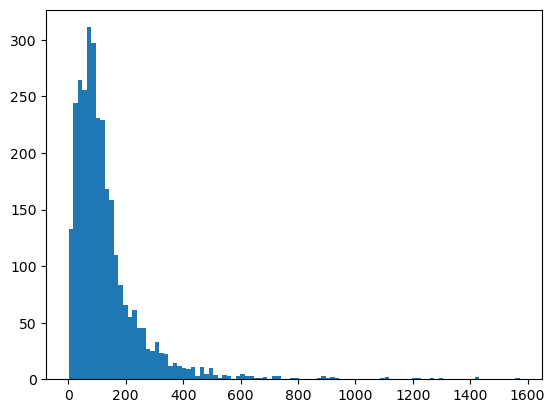

In [308]:
# length of text distribution
plt.hist(df['review'].apply(len), bins=100)
plt.show()

In [309]:
# short reviews
print(df[df['review'].apply(len) < 10])

      label     review
74        2  tuyệt vời
345       2   được tốt
426       0    quá tệ!
615       0      dễ hư
630       0  hàng nhái
779       2    nên mua
839       0    dễ hỏng
881       2   siêu tốt
917       1     OK tạm
992       2    Sắc nét
1106      2   hàng tốt
1137      2   Dùng tốt
1145      1     Máy ổn
1320      2    xài tốt
1362      2  Ngon quá
1394      0        kém
1419      0        xấu
1488      0   nhỏ quá.
1552      2    quá tốt
1554      2       Ngon
1657      0         tệ
1724      0     Loa rè
1756      2   Dùng tốt
1993      2       Được
2009      2    TỐT NHÉ
2076      0   Quá trầy
2095      2  tuyệt vời
2185      2  tốt 5 sao
2254      0     rat te
2327      0         dở
2482      0  không tot
2518      0         Hư
2639      2    Perfect
2646      1  cũng được
2669      1     tạm ổn
2706      0  thất vọng
2765      2  Chuẩn men


In [310]:
# long reviews
long_reviews = df[df['review'].str.len() > 1000]
print(long_reviews.to_string())

      label                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [311]:
# check for encoding errors/ emoij
strange_chars = set("".join(df['review']))
print(strange_chars)

{'\x1f', 'S', 'h', 'i', 'Ữ', 'ỗ', "'", 'ò', 'Z', 'ợ', 'b', 'Đ', '&', 'Ơ', 'Ì', '!', 'ặ', 'J', 'Ỡ', 'm', 'ư', 'ỷ', 'Ỉ', 'ễ', 'ậ', 'Ặ', '❤', 'A', 'ừ', 'ả', 'o', 'ẻ', '_', '7', '℅', 'ọ', 'Q', 'Ự', '5', 'ì', 'q', 'I', 'Ổ', 'ấ', 'Ậ', 'Ũ', ';', '😌', '%', 'Ộ', '.', 'ằ', 'ử', 'è', '\r', 'â', 'L', 'ẩ', 'ẵ', 'Ỹ', 'ị', 'ổ', 'y', 'n', 'p', 'ẽ', 'Ú', 'Ã', '+', 'ỏ', 'R', 'ú', 'j', 'd', 'đ', 'ộ', 'T', 'ữ', 'Ợ', '-', 'Ạ', 'Ồ', '<', '2', '^', '4', 'ỹ', 'Á', 'À', '😁', 'Ù', 'ã', 'ủ', 'ờ', '(', 'z', 'Ế', 'Ý', 'H', '/', '☺', 'ỳ', 'ô', 'õ', '8', '̉', 'é', 'ệ', '́', 'Y', 'Ư', 'ơ', 'Ố', 'Ụ', 'ể', 'á', 'ỡ', '~', 'ẳ', '̀', 'É', '"', 'O', 'ẹ', '\t', '?', 'ồ', 'B', 'Ề', 'ó', 'Ò', 'k', 'ế', ')', 'à', 'ê', 'K', 'v', 'Ẫ', 'Ả', '̣', 'Ă', 'ĩ', 'a', 't', 'ắ', 'ũ', 'ă', '̃', 'f', 'í', '9', 'Ị', '@', 'Ử', 'Ấ', 'Ẽ', 'ề', 'ớ', 'Ệ', '\n', 'x', '😢', 'Ờ', 's', '>', '\xa0', 'Ê', 'r', 'ầ', 'g', 'Ừ', 'e', 'E', 'Ẹ', 'G', '—', '₫', 'X', 'Ô', '6', ':', 'P', 'Ó', 'ạ', 'M', 'N', 'ẫ', 'Ễ', 'ụ', 'ở', '，', 'C', ',', 'ỉ', 'U', 'V', 'c', 

In [312]:
emoji_pattern = re.compile(
    "[" 
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map symbols
    "\U0001F1E0-\U0001F1FF"  # flags (iOS)
    "\u2600-\u26FF"          # miscellaneous symbols
    "\u2700-\u27BF"          # dingbats
    "]+", 
    flags=re.UNICODE
)

emojis = emoji_pattern.findall(" ".join(strange_chars))
print("Found emojis:", emojis)
print("Their names:", emoji.demojize(" ".join(emojis)))

Found emojis: ['❤', '😌', '😁', '☺', '😢', '😆']
Their names: :red_heart: :relieved_face: :beaming_face_with_smiling_eyes: :smiling_face: :crying_face: :grinning_squinting_face:


In [313]:
emoji_map = {
    ":red_heart:": "yêu thích",
    ":relieved_face:": "hài lòng",
    ":beaming_face_with_smiling_eyes:": "cười",
    ":grinning_squinting_face:": "cười",
    ":smiling_face:": "cười",
    ":crying_face:": "buồn"
}

### Preprocessing

In [314]:
stopwords_path = '../data/vietnamese-stopwords.txt'
with open(stopwords_path, 'r', encoding='utf-8') as f:
    STOPWORDS = set([line.strip() for line in f if line.strip()])

In [315]:
def replace_emoji_words(text, emoji_map):
    for k, v in emoji_map.items():
        text = text.replace(k, v.replace(" ", " "))
    return text

In [316]:
def preprocessing(text):
    # 1. Cleaning
    ## UNICODE normalization
    text = unicodedata.normalize("NFC", str(text))
    ## lowercase
    text = text.lower()
    ## remove HTML tags
    text = re.sub(r'<.*?>', '', text) 
    ## remove URLs like http/www & domains like .com, .vn, .net, ...
    text = re.sub(r'http\S+|www\S+', ' ', text) 
    text = re.sub(r'\b[\w-]+\.(?:com|vn|net|org|info|gov|edu)(?:\.[a-z]{2})?\b', ' ', text)
    ## keep emoji and replace by text
    text = emoji.demojize(text)
    text = replace_emoji_words(text, emoji_map)
    ## remove punctuation, strange characters
    text = re.sub(r'[^\w\s]', ' ', text)
    ## remove extra white space
    text = re.sub(r"\s+", " ", text).strip()

    # 2. Tokenization
    # tokens = word_tokenize(text, format="list")
    
    # 3. Remove stopwords
    # tokens = [w for w in tokens if w not in STOPWORDS]
    
    return text

In [317]:
processed_df = new_df.copy()
processed_df['review'] = processed_df['review'].apply(preprocessing)

In [318]:
# create manual stopword list by counter
all_text = " ".join(processed_df['review'])
tokens = word_tokenize(all_text, format="list")
counter = Counter(tokens)

In [319]:
single_char_tokens = [t for t in tokens if len(t) == 1]
print(single_char_tokens)

['4', 'g', '4', 'g', '4', 'g', '2', '4', 'g', '1', '3', '5', '5', '2', '3', '6', 'k', '3', '4', '1', 'h', '6', '2', 'ạ', 'h', 'ở', '4', 'g', 'ở', '2', 'á', 'ý', '3', '1', '5', 'ạ', 'ở', '1', '4', '1', '5', 'ở', 'ở', '2', '2', '2', '3', '5', 'ư', '1', 'ạ', 'p', '6', '4', 'k', '5', 'd', 'ạ', '4', 'g', '1', '5', 'ở', 'h', 'ở', 'k', 'k', '1', '1', 'k', '8', 'ạ', '9', 'h', '3', 'h', '5', '3', '1', '5', '5', 'ở', '3', '2', 'h', '4', 'g', 'ở', '1', '2', '4', 'g', 'ở', '1', '5', '6', '2', '4', 'g', 'k', '6', '4', 'g', '5', '5', 'ở', '1', '1', '4', 'g', '2', 'k', '3', 'g', '1', 'k', '7', '3', 'g', '1', '4', 'g', 'ở', '5', '1', 'ở', '5', 'k', 'ở', '3', 'g', 'ạ', '8', 'h', 'ạ', '4', '6', '2', '1', '1', '1', '4', 'g', '4', 'g', 'ở', '3', '5', 'ở', '5', '3', '4', 'g', '2', 'h', '4', 'g', '1', 'ở', '3', '4', 'g', '2', '1', '1', '5', '5', 'r', 'ạ', '1', '5', '6', '4', 'g', 'k', '1', 'k', '1', '1', '1', '2', 'k', '5', '4', '4', 'g', 'ở', '9', 'h', '4', 'm', '1', '1', '4', 'g', '2', 'ở', 'k', '5', '1',

In [320]:
print(counter.most_common(1000))

[('không', 2409), ('được', 1557), ('hàng', 1389), ('tốt', 1031), ('thì', 995), ('có', 979), ('mình', 938), ('sản phẩm', 925), ('rất', 901), ('mua', 799), ('nhưng', 767), ('là', 748), ('dùng', 745), ('giao', 687), ('bị', 631), ('và', 586), ('nghe', 583), ('1', 571), ('với', 561), ('hài lòng', 519), ('nhanh', 477), ('pin', 465), ('đã', 465), ('này', 443), ('cho', 421), ('máy', 414), ('mới', 412), ('như', 409), ('nên', 407), ('chuột', 403), ('sử dụng', 403), ('cũng', 397), ('lại', 395), ('tiki', 394), ('khi', 382), ('mà', 369), ('giá', 367), ('chất lượng', 365), ('của', 361), ('quá', 356), ('thấy', 356), ('nhận', 349), ('2', 348), ('cửa hàng', 342), ('về', 338), ('hơn', 316), ('khá', 315), ('còn', 312), ('phải', 312), ('trong', 302), ('để', 301), ('sao', 298), ('chưa', 287), ('rồi', 281), ('xài', 271), ('hơi', 270), ('ngày', 270), ('cái', 269), ('tai', 264), ('kết nối', 262), ('nhiều', 257), ('chỉ', 253), ('sạc', 250), ('ổn', 250), ('shop', 243), ('lỗi', 242), ('bảo hành', 237), ('đúng', 

In [321]:
CUSTOM_STOPWORDS = {'thì', 'mà', 'là', 'của', 'với', 'trong', 'trên', 'khi', 'như', 'đã', 'này', 'để', 'tôi'}
def remove_stopwords(text):
    # Tokenization
    tokens = word_tokenize(text, format="list")
    
    # Remove stopwords
    tokens = [w for w in tokens if w not in CUSTOM_STOPWORDS]
    
    return " ".join(tokens)

In [322]:
processed_df['review'] = processed_df['review'].apply(remove_stopwords)

In [323]:
processed_df.shape

(2997, 2)

In [324]:
for i in range(50):
    print(f"Review {i+1}:")
    print(processed_df['review'][i])

Review 1:
chỉ có dây cáp nguồn không có adapter sao sử dụng chỉ có dây cáp nguồn không có adapter sao sử dụng hàng tiki training gì kì cục vậy
Review 2:
chất lượng quá kém mới dùng được 2 ngày loa bass có âm thanh rè rè dù không mở gì không tin tưởng được chất lượng
Review 3:
usb vừa mới nhận usb rất bực bội vì cái nắp usb rất cứng không thể mở ra được và cái hộp đựng usb dường như bị ai đó cắt ra trước đó
Review 4:
tuyệt vời hàng fpt cửa hàng
Review 5:
chưa đo đúng bước chân rõ nhiều gián đoạn chưa hài lòng hàng không có tiếng việt nên rất khó tìm hiểu về các hoạt động máy
Review 6:
phủ sóng thấp quá đi khoảng 3 4 m mất sóng
Review 7:
kết nối tốt mối nối không khít gây đau tai 1 kết nối nhiều bạn cũng nói vấn đề rồi kết nối tốt tiện dụng 2 mối nối có 1 bạn cũng gặp trường hợp giống mình mối nối không khớp nhau ở một số điểm đeo vào thấy hơi hơi khó chịu đeo lâu gây đau tai cực ban đầu mình không nghĩ đây vấn đề lớn nên không liên hệ đổi trả bây giờ có cơ hội so tai bạn mình mới vỡ ra 

In [325]:
processed_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2997 entries, 3038 to 1510
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   2997 non-null   int64 
 1   review  2997 non-null   object
dtypes: int64(1), object(1)
memory usage: 134.8+ KB


### Train-test split

In [326]:
X = processed_df['review']
y = processed_df['label'].values

In [327]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Vectorizer

Using both BoW and TF-IDF for experiments

#### Bag of Words

In [328]:
bow_vectorizer = CountVectorizer(ngram_range=(1,2))
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

#### TF-IDF

In [329]:
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [330]:
print(tfidf_vectorizer.get_feature_names_out())

['00' '00 hôm' '00 ngày' ... 'ứng vân' 'ứng vậy' 'ứng được']


### Classification

#### Experiment 1: MultinomialNB + BoW

In [331]:
nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)
y_pred_nb_bow = nb_model.predict(X_test_bow)

#### Experiment 2: SVM + BoW

In [332]:
svm_model = SVC(kernel='rbf', class_weight='balanced')
svm_model.fit(X_train_bow, y_train)
y_pred_svm_bow = svm_model.predict(X_test_bow)

#### Experiment 3: Multinomial + TF-IDF

In [333]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb_tfidf = nb_model.predict(X_test_tfidf)

#### Experiment 4: SVM + TF-IDF

In [334]:
svm_model = SVC(kernel='rbf', class_weight='balanced')
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm_tfidf = svm_model.predict(X_test_tfidf)

### Model Evaluation

In [335]:
def calculate_metrics(y_pred, y_test, model_name):
    accuracy = accuracy_score(y_test, y_pred)
    classification_rp = classification_report(y_test, y_pred)
    cfs_mx = confusion_matrix(y_test, y_pred)
    
    print("Evaluate", {model_name}, "model:")
    print(f"Accuracy score: {accuracy:.4f}")
    print(f"Classification report: \n{classification_rp}")
    print(f"Confusion matrix: \n{cfs_mx}")

    main_metric = accuracy
    return main_metric

In [336]:
_ = calculate_metrics(y_pred_nb_bow, y_test, 'MultinomialNB + BoW')

Evaluate {'MultinomialNB + BoW'} model:
Accuracy score: 0.8100
Classification report: 
              precision    recall  f1-score   support

           0       0.85      0.82      0.84       218
           1       0.65      0.70      0.68       154
           2       0.88      0.87      0.88       228

    accuracy                           0.81       600
   macro avg       0.80      0.80      0.80       600
weighted avg       0.81      0.81      0.81       600

Confusion matrix: 
[[179  32   7]
 [ 27 108  19]
 [  4  25 199]]


In [337]:
_ = calculate_metrics(y_pred_svm_bow, y_test, 'SVM + BoW')

Evaluate {'SVM + BoW'} model:
Accuracy score: 0.8050
Classification report: 
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       218
           1       0.65      0.72      0.69       154
           2       0.89      0.81      0.85       228

    accuracy                           0.81       600
   macro avg       0.80      0.80      0.79       600
weighted avg       0.81      0.81      0.81       600

Confusion matrix: 
[[187  28   3]
 [ 24 111  19]
 [ 12  31 185]]


In [338]:
_ = calculate_metrics(y_pred_nb_tfidf, y_test, 'MultinomialNB + TF-IDF')

Evaluate {'MultinomialNB + TF-IDF'} model:
Accuracy score: 0.8050
Classification report: 
              precision    recall  f1-score   support

           0       0.78      0.92      0.85       218
           1       0.79      0.51      0.62       154
           2       0.83      0.90      0.86       228

    accuracy                           0.81       600
   macro avg       0.80      0.77      0.78       600
weighted avg       0.80      0.81      0.79       600

Confusion matrix: 
[[200   8  10]
 [ 45  78  31]
 [ 10  13 205]]


In [339]:
_ = calculate_metrics(y_pred_svm_tfidf, y_test, 'SVM + TF-IDF')

Evaluate {'SVM + TF-IDF'} model:
Accuracy score: 0.8133
Classification report: 
              precision    recall  f1-score   support

           0       0.84      0.87      0.85       218
           1       0.66      0.71      0.69       154
           2       0.90      0.83      0.87       228

    accuracy                           0.81       600
   macro avg       0.80      0.80      0.80       600
weighted avg       0.82      0.81      0.81       600

Confusion matrix: 
[[189  24   5]
 [ 29 109  16]
 [  7  31 190]]


### GridSearch

In [228]:
# MuitinomialNB
param_grid = {
    'alpha': [0.1, 0.5, 1.0] 
}
gridsearch = GridSearchCV(MultinomialNB(), param_grid, scoring="accuracy", n_jobs=2)
gridsearch.fit(X_train_tfidf, y_train)

GridSearchCV(estimator=MultinomialNB(), n_jobs=2,
             param_grid={'alpha': [0.1, 0.5, 1.0]}, scoring='accuracy')

In [229]:
# examine the best model
# best score achieved during the GridSearchCV
print('GridSearch CV best score : {:.4f}\n\n'.format(gridsearch.best_score_))

# print parameters that give the best results
print('Parameters that give the best results :','\n\n', (gridsearch.best_params_))

# print estimator that was chosen by the GridSearch
print('\n\nEstimator that was chosen by the search :','\n\n', (gridsearch.best_estimator_))

GridSearch CV best score : 0.7768


Parameters that give the best results : 

 {'alpha': 0.1}


Estimator that was chosen by the search : 

 MultinomialNB(alpha=0.1)


In [230]:
# calculate GridSearch CV score on test set
print('GridSearch CV score on test set: {0:0.4f}'.format(gridsearch.score(X_test_tfidf, y_test)))

GridSearch CV score on test set: 0.8050


In [231]:
# SVM
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100, 1000],
    "gamma": ["scale", 0.001, 0.005, 0.1],
    "class_weight": [None, 'balanced']
}
gridsearch = GridSearchCV(
    SVC(random_state=42), 
    param_grid, cv=5, scoring="accuracy", verbose=2
)

In [232]:
gridsearch.fit(X_train_tfidf, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END .............C=0.01, class_weight=None, gamma=scale; total time=   2.7s
[CV] END .............C=0.01, class_weight=None, gamma=scale; total time=   2.6s
[CV] END .............C=0.01, class_weight=None, gamma=scale; total time=   2.6s
[CV] END .............C=0.01, class_weight=None, gamma=scale; total time=   2.6s
[CV] END .............C=0.01, class_weight=None, gamma=scale; total time=   2.6s
[CV] END .............C=0.01, class_weight=None, gamma=0.001; total time=   3.6s
[CV] END .............C=0.01, class_weight=None, gamma=0.001; total time=   2.6s
[CV] END .............C=0.01, class_weight=None, gamma=0.001; total time=   2.6s
[CV] END .............C=0.01, class_weight=None, gamma=0.001; total time=   2.6s
[CV] END .............C=0.01, class_weight=None, gamma=0.001; total time=   2.6s
[CV] END .............C=0.01, class_weight=None, gamma=0.005; total time=   2.7s
[CV] END .............C=0.01, class_weight=None

GridSearchCV(cv=5, estimator=SVC(random_state=42),
             param_grid={'C': [0.01, 0.1, 1, 10, 100, 1000],
                         'class_weight': [None, 'balanced'],
                         'gamma': ['scale', 0.001, 0.005, 0.1]},
             scoring='accuracy', verbose=2)

In [233]:
# examine the best model
# best score achieved during the GridSearchCV
print('GridSearch CV best score : {:.4f}\n\n'.format(gridsearch.best_score_))

# print parameters that give the best results
print('Parameters that give the best results :','\n\n', (gridsearch.best_params_))

# print estimator that was chosen by the GridSearch
print('\n\nEstimator that was chosen by the search :','\n\n', (gridsearch.best_estimator_))

GridSearch CV best score : 0.8085


Parameters that give the best results : 

 {'C': 100, 'class_weight': 'balanced', 'gamma': 0.005}


Estimator that was chosen by the search : 

 SVC(C=100, class_weight='balanced', gamma=0.005, random_state=42)


In [234]:
# calculate GridSearch CV score on test set
print('GridSearch CV score on test set: {0:0.4f}'.format(gridsearch.score(X_test_tfidf, y_test)))

GridSearch CV score on test set: 0.8067


### Compare the results

The observable results above clearly show the intrinsic difference between Naive Bayes and SVM when using different text processing techniques.

- With Naive Bayes, using BoW usually gives better results because NB is designed for word frequency count data, which fits the multinomial distribution assumption. In this case, NB makes good use of the information from the actual occurrences of words in the text. 
- In contrast, when using SVM with BoW, frequent words are easily over-weighted, causing noise and reducing the model's ability to separate words. However, when switching to TF-IDF, the situation is reversed: SVM outperforms NB. The reason is that TF-IDF reduces the influence of frequent words and emphasizes characteristic words, helping SVM — which is a discriminative model — learn the optimal hyperplane for classification. 